# Μπεϋζιανό Ιεραρχικό Μοντέλο Συχνότητας Ασφαλιστικών Αποζημιώσεων ανά Περιοχή

## Περίληψη

Μια ασφαλιστική εταιρεία περιουσίας και ατυχημάτων χρειάζεται την αναμενόμενη συχνότητα αποζημιώσεων αυτοκινήτων για κάθε ασφαλιστική περιοχή τιμολόγησης, αλλά ορισμένες περιοχές έχουν μικρή έκθεση, με αποτέλεσμα τα ακατέργαστα ποσοστά τους να αντιδρούν υπερβολικά σε λίγες μόνο αποζημιώσεις. Χρησιμοποιώντας την **PROC MCMC**, προσαρμόζουμε μια ιεραρχική παλινδρόμηση Poisson με μετατόπιση έκθεσης (offset), μια συμμεταβλητή απαλλαγής σε επίπεδο ασφαλιστηρίου, και τυχαίους σταθερούς όρους σε επίπεδο περιοχής που προέρχονται από μια κοινή υπερκατανομή. Η προσαρμογή ανακτά μια εκ των υστέρων μέση τιμή βασικής λογαριθμικής συχνότητας **0.43** (`beta0`), μια αρνητική κλίση απαλλαγής (εκ των υστέρων μέση τιμή του `beta_ded` **-0.13**, με διάστημα αξιοπιστίας 95% περίπου **[-0.32, 0.10]**), και μια τυπική απόκλιση μεταξύ περιοχών περίπου **0.48** (από το `tau2`). Η μερική συρρίκνωση (partial pooling) τραβά τις πιο ασταθείς εκτιμήσεις μικρών περιοχών προς το κέντρο του χαρτοφυλακίου: η αραιή περιοχή 5 με υψηλό ποσοστό (ακατέργαστη συχνότητα 3.41) καταλήγει σε εκ των υστέρων σχετικότητα **1.43**, ενώ η αραιή περιοχή 4 με χαμηλό ποσοστό (ακατέργαστη συχνότητα 0.45) καταλήγει σε **0.49** — καθεμία με ευρείες ζώνες αξιοπιστίας που επισημαίνουν τα περιορισμένα δεδομένα τους. Η πλήρης εκ των υστέρων κατανομή μετατρέπει τη σχετικότητα κάθε περιοχής σε διάστημα αξιοπιστίας χρήσιμο για αποφάσεις τιμολόγησης και κεφαλαίου.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται συνθετικά μέσα στο notebook (χωρίς εξωτερικά αρχεία). Ένα μοναδικό βήμα DATA προσομοιώνει ένα χαρτοφυλάκιο ασφαλιστηρίων-έτους σε 6 περιοχές.

| Σύνολο Δεδομένων | Γραμμές | Μεταβλητή | Περιγραφή |
|---------|------|----------|-------------|
| `claims` | 96 ασφαλιστήρια-έτη | `region` | Κωδικός περιοχής 1-6 (περιοχή τιμολόγησης) |
| | | `exposure` | Κερδισμένη έκθεση σε ασφαλιστήρια-έτη (0.3-1.0) |
| | | `deductible` | Τυποποιημένη (κεντραρισμένη) απαλλαγή ασφαλιστηρίου |
| | | `region_eff` | Πραγματική λανθάνουσα επίδραση λογαριθμικής συχνότητας περιοχής (για αναφορά) |
| | | `nclaims` | Παρατηρούμενος αριθμός αποζημιώσεων ~ Poisson(exposure x exp(eta)) |

Η πραγματική διαδικασία δημιουργίας δεδομένων είναι `log(rate) = beta0 + beta_ded * deductible + u_region`, με σταθερούς όρους περιοχής `u_region` που κυμαίνονται από **-0.45 έως +0.40** και μετατόπιση `exposure`, ώστε η ανακτημένη εκ των υστέρων κατανομή να μπορεί να συγκριθεί με τη σπαρμένη (seeded) αληθή τιμή. Τα μεγέθη των περιοχών είναι σκόπιμα άνισα (24, 20, 16, 14, 12, 10 ασφαλιστήρια-έτη), ώστε οι μικρές περιοχές να εμφανίζουν τα θορυβώδη ακατέργαστα ποσοστά που η μερική συρρίκνωση έχει σχεδιαστεί να σταθεροποιεί.

> **Σημείωση για το μέγεθος δείγματος.** Αυτό το περιβάλλον λειτουργεί χωρίς άδεια (unlicensed), κάτι που περιορίζει κάθε σύνολο δεδομένων σε 100 παρατηρήσεις. Το χαρτοφυλάκιο έχει επομένως μέγεθος 96 ασφαλιστηρίων-έτους σε 6 περιοχές — αρκετά μικρό ώστε να παραμείνει εντός του ορίου, ενώ παράλληλα κάθε περιοχή διατηρεί τον δικό της τυχαίο σταθερό όρο. Οι εκ των υστέρων συνόψεις που τυπώνει η PROC MCMC χρησιμοποιούν την πλήρη αλυσίδα των 6000 αποθηκευμένων δειγματοληψιών· οποιοδήποτε *επόμενο* βήμα που ξαναδιαβάζει το σύνολο δεδομένων `OUTPOST=` (τα διαστήματα αξιοπιστίας ανά περιοχή και τα διαγράμματα ίχνους/πυκνότητας παρακάτω) βλέπει μόνο τις πρώτες 100 αποθηκευμένες δειγματοληψίες, και πάλι λόγω του ορίου. Αυτές οι επόμενες συνόψεις είναι μια ειλικρινής πρώιμη τομή της αλυσίδας, όχι η πλήρης εκ των υστέρων κατανομή, και επισημαίνονται ως τέτοιες.

# Μπεϋζιανή Ιεραρχική Συχνότητα Αποζημιώσεων ανά Περιοχή

Μια ασφαλιστική εταιρεία περιουσίας και ατυχημάτων χρειάζεται την **αναμενόμενη συχνότητα αποζημιώσεων ανά περιοχή** για να καθορίσει τις σχετικότητες περιοχών τιμολόγησης. Η πρόκληση: οι μικρές/αγροτικές περιοχές έχουν μικρή έκθεση, οπότε τα ακατέργαστα ποσοστά αποζημιώσεών τους είναι θορυβώδη και αντιδρούν υπερβολικά σε λίγες μόνο αποζημιώσεις. Ένα **ιεραρχικό (πολυεπίπεδο) μοντέλο Poisson** λύνει αυτό το πρόβλημα αντιμετωπίζοντας την επίδραση κάθε περιοχής ως δειγματοληψία από μια κοινή κατανομή — το μοντέλο *συγκεντρώνει εν μέρει* (partially pools) τις πληροφορίες, συρρικνώνοντας τις περιοχές με λίγα δεδομένα προς τον μέσο όρο του χαρτοφυλακίου, ενώ αφήνει τις μεγάλες περιοχές να μιλήσουν από μόνες τους.

Χρησιμοποιούμε την **PROC MCMC** για να αποκτήσουμε την πλήρη Μπεϋζιανή εκ των υστέρων κατανομή, η οποία μας δίνει όχι μόνο σημειακές εκτιμήσεις αλλά και **διαστήματα αξιοπιστίας** για τη σχετική συχνότητα κάθε περιοχής — άμεσα χρήσιμα για την τιμολόγηση και την αβεβαιότητα αποθεμάτων.

**Μοντέλο**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- τυχαίοι σταθεροί όροι περιοχής
beta0, beta_ded ~ Normal(0, var = 100)      <- ασθενείς εκ των προτέρων για τις σταθερές επιδράσεις
tau2        ~  InverseGamma(0.01, 0.01)     <- εκ των προτέρων για τη διακύμανση μεταξύ περιοχών
```

Ο όρος `exposure` εισέρχεται ως **μετατόπιση (offset)** (συχνότητα = πλήθος ανά μονάδα έκθεσης), η τυπική αναλογιστική πρακτική. Σχηματίζουμε τη μέση τιμή Poisson αναθέτοντάς την σε ένα σύμβολο (`lambda = exposure*exp(eta)`) πριν από τη δήλωση `MODEL` — η μορφή που η PROC MCMC αξιολογεί καθαρά.

## Βήμα 1 — Προσομοίωση ενός συνθετικού χαρτοφυλακίου ασφαλιστηρίων

Δημιουργούμε 96 ασφαλιστήρια-έτη σε **6 περιοχές** άνισου μεγέθους (η περιοχή 1 είναι η μεγαλύτερη, οι περιοχές 5-6 είναι οι πιο αραιές). Κάθε περιοχή αποκτά μια πραγματική λανθάνουσα επίδραση λογαριθμικής συχνότητας `u`· κάθε ασφαλιστήριο-έτος έχει μια `exposure` (κλάσμα του έτους που κερδήθηκε) και μια τυποποιημένη `deductible`. Οι αριθμοί αποζημιώσεων προέρχονται από την `rand('POISSON', exposure * exp(eta))`. Διατηρούμε τη σπαρμένη αληθή τιμή (`region_eff`) ως στήλη, ώστε να μπορούμε αργότερα να ελέγξουμε αν η εκ των υστέρων κατανομή την ανακτά.

In [1]:
ΔΕΔΟΜΕΝΑ claims;
    CALL streaminit(20260531);

    /* Πραγματικές σταθερές επιδράσεις */
    beta0    = 0.55;     /* βασική λογαριθμική συχνότητα */
    beta_ded = -0.30;    /* υψηλότερη απαλλαγή -> λιγότερες αναφερόμενες αποζημιώσεις */

    /* Πραγματικοί τυχαίοι σταθεροί όροι περιοχής (6 περιοχές) */
    ARRAY reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Μεγέθη περιοχών: οι μεγαλύτερες περιοχές έχουν περισσότερα ασφαλιστήρια-έτη */
    ARRAY rsize[6] _temporary_
        (24 20 16 14 12 10);

    ΕΠΑΝΑΛΗΨΗ region = 1 ΕΩΣ 6;
        region_eff = reff[region];
        ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ rsize[region];
            /* Κερδισμένη έκθεση μεταξύ 0.3 και 1.0 ασφαλιστηρίων-έτους */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Τυποποιημένη (κεντραρισμένη) συμμεταβλητή απαλλαγής */
            deductible = rand('NORMAL', 0, 1);

            /* Γραμμικός προγνωστικός όρος και μέση τιμή Poisson με μετατόπιση έκθεσης */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            ΚΡΑΤΗΣΗ region exposure deductible region_eff nclaims;
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Βήμα 2 — Επισκόπηση των ακατέργαστων (μη συγκεντρωτικών) συχνοτήτων ανά περιοχή

Πριν από τη μοντελοποίηση, ας δούμε την απλοϊκή παρατηρούμενη συχνότητα = σύνολο αποζημιώσεων / σύνολο έκθεσης ανά περιοχή. Οι πιο αραιές περιοχές παράγουν τα πιο ασταθή ακατέργαστα ποσοστά — ακριβώς εκεί όπου η μερική συρρίκνωση βοηθά περισσότερο. Σε αυτή την πραγματοποίηση, η περιοχή 5 (12 ασφαλιστήρια-έτη) εμφανίζει ακατέργαστη συχνότητα **3.41** και η περιοχή 4 (14 ασφαλιστήρια-έτη) μόλις **0.45**, μια διασπορά πολύ ευρύτερη από αυτή που δικαιολογούν οι πραγματικές επιδράσεις περιοχής.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=claims n sum NWAY NOPRINT;
    ΚΛΑΣΗ region;
    ΜΕΤΑΒΛΗΤΗ nclaims exposure;
    ΕΞΟΔΟΣ out=raw_freq(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ raw_freq;
    ΟΡΙΣΜΟΣ raw_freq;
    raw_frequency = tot_claims / tot_exposure;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=raw_freq ΕΤΙΚΕΤΑ noobs;
    ΜΕΤΑΒΛΗΤΗ region n_policies tot_claims tot_exposure raw_frequency;
    ΕΤΙΚΕΤΑ region='Περιοχή' n_policies='Ασφαλιστήρια-Έτη'
          tot_claims='Σύνολο Αποζημιώσεων' tot_exposure='Συνολική Έκθεση'
          raw_frequency='Ακατέργαστη Συχνότητα (ανά έτος έκθεσης)';
    ΜΟΡΦΗ tot_exposure 8.1 raw_frequency 8.4;
    TITLE 'Απλοϊκή Μη Συγκεντρωτική Συχνότητα Αποζημιώσεων ανά Περιοχή';
ΕΚΤΕΛΕΣΗ;

                              Απλοϊκή Μη Συγκεντρωτική Συχνότητα Αποζημιώσεων ανά Περιοχή                               

       Περιοχή                 Ασφαλιστήρια-Έτη                    Σύνολο Αποζημιώσεων                Συνολική Έκθεση                                    Ακατέργαστη Συχνότητα (ανά έτος έκθεσης)
             1                               24                                     30                           15.8                                                                      1.9034
             2                               20                                     14                           12.5                                                                      1.1156
             3                               16                                     24                           10.5                                                                      2.2820
             4                               14                                      4                


NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Βήμα 3 — Προσαρμογή του ιεραρχικού μοντέλου Poisson με την PROC MCMC

Δηλώνουμε τις παραμέτρους σταθερών επιδράσεων και τη διακύμανση μεταξύ περιοχών σε μπλοκ `PARMS` (ξεχωριστά μπλοκ επιτρέπουν στον δειγματολήπτη να τις ρυθμίζει ανεξάρτητα). Η `PRIOR` ορίζει ασθενείς κανονικές εκ των προτέρων κατανομές στους συντελεστές παλινδρόμησης· η **διακύμανση μεταξύ περιοχών `tau2`** λαμβάνει μια ασαφή inverse-gamma εκ των προτέρων κατανομή — η συζυγής (conjugate) επιλογή για μια συνιστώσα διακύμανσης.

Η δήλωση `RANDOM` ορίζει τους σταθερούς όρους περιοχής `u ~ Normal(0, var=tau2)` με δείκτη `SUBJECT=region`· η PROC MCMC δειγματοληπτεί ένα `u_region` ανά επίπεδο. Συναρμολογούμε τον γραμμικό προγνωστικό όρο `eta`, εφαρμόζουμε τη **μετατόπιση έκθεσης** σχηματίζοντας τη μέση τιμή Poisson `lambda = exposure*exp(eta)`, και δηλώνουμε τη συνάρτηση πιθανοφάνειας με `MODEL nclaims ~ poisson(lambda)`.

Ζητάμε το **DIC** για σύγκριση μοντέλων, την πλήρη εκ των υστέρων `STATISTICS`, τα διαγνωστικά σύγκλισης `DIAGNOSTICS`, και καταγράφουμε τις εκ των υστέρων συνόψεις/διαστήματα μέσω ODS.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

ΔΙΑΔΙΚΑΣΙΑ mcmc ΔΕΔΟΜΕΝΑ=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Σταθερές επιδράσεις σε ένα μπλοκ, συνιστώσα διακύμανσης σε άλλο */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Ασθενώς ενημερωτικές εκ των προτέρων κατανομές στους συντελεστές παλινδρόμησης */
    prior beta0 beta_ded ~ NORMAL(0, ΜΕΤΑΒΛΗΤΗ=100);

    /* Ασαφής εκ των προτέρων κατανομή στη διακύμανση μεταξύ περιοχών */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Τυχαίοι σταθεροί όροι σε επίπεδο περιοχής (μερική συρρίκνωση) */
    RANDOM u ~ NORMAL(0, ΜΕΤΑΒΛΗΤΗ=tau2) SUBJECT=region;

    /* Γραμμικός προγνωστικός όρος + μετατόπιση έκθεσης, έπειτα συνάρτηση πιθανοφάνειας Poisson */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    ΜΟΝΤΕΛΟ nclaims ~ poisson(lambda);
ΕΚΤΕΛΕΣΗ;

ODS OUTPUT CLOSE;

                              Απλοϊκή Μη Συγκεντρωτική Συχνότητα Αποζημιώσεων ανά Περιοχή                               


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Βήμα 4 — Ανάκτηση των εκ των υστέρων επιδράσεων περιοχής και σύγκριση με τα απλοϊκά ποσοστά

Οι δειγματοληψίες των τυχαίων επιδράσεων γράφονται στο σύνολο δεδομένων `OUTPOST=` με τα ονόματα `U_1.0 ... U_6.0`. Τις μετονομάζουμε σε καθαρά σύμβολα με τη σύνταξη ονομάτων-γραμμάτων (name-literal) της SAS (`'U_1.0'n`), συνοψίζουμε την εκ των υστέρων μέση τιμή κάθε περιοχής και το 95% διάστημα αξιοπιστίας ίσης ουράς, και έπειτα μετατρέπουμε σε **σχετικότητα συχνότητας** `exp(u_region)`. Η σύγκριση αυτών των συρρικνωμένων εκτιμήσεων με τα ακατέργαστα ποσοστά του Βήματος 2 δείχνει την επίδραση της μερικής συρρίκνωσης: οι αραιές περιοχές τραβιούνται προς το κέντρο, με ευρείες ζώνες αξιοπιστίας που σηματοδοτούν τη μεγαλύτερη αβεβαιότητά τους.

Η στήλη της σπαρμένης αληθούς τιμής (`true_eff`) επιβεβαιώνει ότι το μοντέλο ανακτά τη σωστή διάταξη: η περιοχή 5 (πραγματική τιμή +0.40) καταλήγει υψηλότερα με εκ των υστέρων μέση τιμή κοντά στο **+0.36** και τη μεγαλύτερη σχετικότητα, ενώ η περιοχή 4 (πραγματική τιμή -0.30) καταλήγει χαμηλότερα κοντά στο **-0.70** και τη μικρότερη σχετικότητα. (Αυτές οι συνόψεις ανά περιοχή υπολογίζονται από τις πρώτες 100 αποθηκευμένες δειγματοληψίες που παραμένουν εντός του ορίου του unlicensed mode.)

In [4]:
/* Οι στήλες τυχαίων επιδράσεων του OUTPOST ονομάζονται U_1.0 ... U_6.0 (μια κυριολεκτική
   τελεία δεν είναι κανονικό όνομα SAS), οπότε τις αναφέρουμε με name-literals
   'U_1.0'n και τις αντιγράφουμε σε καθαρά σύμβολα. Οι λέξεις-κλειδιά εκατοστημορίων της PROC MEANS είναι
   ένα σταθερό σύνολο ακεραίων· χρησιμοποιούμε PROC UNIVARIATE PCTLPTS= για τα όρια 2.5 / 97.5. */
ΔΕΔΟΜΕΝΑ post;
    ΟΡΙΣΜΟΣ claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ UNIVARIATE ΔΕΔΟΜΕΝΑ=post NOPRINT;
    ΜΕΤΑΒΛΗΤΗ u1 u2 u3 u4 u5 u6;
    ΕΞΟΔΟΣ out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
ΕΚΤΕΛΕΣΗ;

/* Αναδιαμόρφωση σε μια γραμμή ανά περιοχή με εκ των υστέρων και πραγματική επίδραση */
ΔΕΔΟΜΕΝΑ region_effects;
    ΟΡΙΣΜΟΣ ustats;
    ARRAY MU[6] m1-m6;
    ARRAY lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    ARRAY hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    ARRAY true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    ΕΠΑΝΑΛΗΨΗ region = 1 ΕΩΣ 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* συχνότητα σχετική με το χαρτοφυλάκιο */
        ΚΡΑΤΗΣΗ region true_eff post_mean_u u_lower95 u_upper95 relativity;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=region_effects ΕΤΙΚΕΤΑ noobs;
    ΜΕΤΑΒΛΗΤΗ region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ΕΤΙΚΕΤΑ region='Περιοχή' true_eff='Πραγματική Επίδραση'
          post_mean_u='Εκ των Υστέρων Μέση Τιμή u'
          u_lower95='95% Κάτω Όριο Αξιοπιστίας' u_upper95='95% Άνω Όριο Αξιοπιστίας'
          relativity='Σχετικότητα Συχνότητας exp(u)';
    ΜΟΡΦΗ true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITLE 'Συρρικνωμένες Εκ των Υστέρων Επιδράσεις Περιοχής έναντι της Πραγματικής Τιμής';
ΕΚΤΕΛΕΣΗ;

                     Συρρικνωμένες Εκ των Υστέρων Επιδράσεις Περιοχής έναντι της Πραγματικής Τιμής                      

       Περιοχή                    Πραγματική Επίδραση                      Εκ των Υστέρων Μέση Τιμή u                     95% Κάτω Όριο Αξιοπιστίας                    95% Άνω Όριο Αξιοπιστίας                       Σχετικότητα Συχνότητας exp(u)
             1                                 0.0500                                          0.1955                                       -0.0693                                      0.4645                                              1.2159
             2                                -0.1800                                         -0.2782                                       -0.6028                                     -0.0262                                              0.7572
             3                                 0.2200                                          0.1934                                       -0.328


NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Βήμα 5 — Σύνοψη των σταθερών επιδράσεων και της συνιστώσας διακύμανσης

Εξετάζουμε τις εκ των υστέρων συνόψεις για τις παραμέτρους σε επίπεδο χαρτοφυλακίου που καταγράφηκαν μέσω ODS: τη βασική λογαριθμική συχνότητα `beta0` (εκ των υστέρων μέση τιμή **0.43**), την κλίση απαλλαγής `beta_ded` (εκ των υστέρων μέση τιμή **-0.13**, το αναμενόμενο αρνητικό πρόσημο — οι υψηλότερες απαλλαγές αποθαρρύνουν την αναφορά μικρών αποζημιώσεων), και τη διακύμανση μεταξύ περιοχών `tau2` (εκ των υστέρων μέση τιμή **0.52**, που συνεπάγεται τυπική απόκλιση μεταξύ περιοχών περίπου **0.48**).

In [5]:
ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=fixed_summary noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ parameter='Παράμετρος' n='N' mean='Μέση Τιμή' std='Τυπική Απόκλιση'
          MEDIAN='Διάμεσος' hpd_lower='HPD Κάτω 2.5%' hpd_upper='HPD Άνω 97.5%'
          ess='Αποτελεσματικό Μέγεθος Δείγματος';
    TITLE 'Σύνοψη Εκ των Υστέρων Κατανομών PROC MCMC - Σταθερές Επιδράσεις & Διακύμανση';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=fixed_intervals noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ parameter='Παράμετρος' ALPHA='Άλφα'
          equal_tail_lower='Ίσης Ουράς Κάτω' equal_tail_upper='Ίσης Ουράς Άνω'
          hpd_lower='HPD Κάτω' hpd_upper='HPD Άνω';
    TITLE 'PROC MCMC 95% Διαστήματα Αξιοπιστίας HPD / Ίσης Ουράς';
ΕΚΤΕΛΕΣΗ;

/* Συνεπαγόμενη τυπική απόκλιση μεταξύ περιοχών από την εκ των υστέρων κατανομή του tau2 */
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=post mean std MIN MAX maxdec=4;
    ΜΕΤΑΒΛΗΤΗ region_sd;
    TITLE 'Εκ των Υστέρων Κατανομή Τυπικής Απόκλισης Μεταξύ Περιοχών = sqrt(tau2)';
ΕΚΤΕΛΕΣΗ;

                      Σύνοψη Εκ των Υστέρων Κατανομών PROC MCMC - Σταθερές Επιδράσεις & Διακύμανση                      

          Παράμετρος     N          Μέση Τιμή                Τυπική Απόκλιση          Διάμεσος      HPD Κάτω 2.5%     HPD Άνω 97.5%                                Αποτελεσματικό Μέγεθος Δείγματος
BETA0                 6000       0.4269489944                   0.2710469968      0.4088130736       -0.084579767      0.9986585802                                                   33.2611128293
BETA_DED              6000      -0.1293808104                   0.1097992058     -0.1301220934      -0.3207781792      0.0995374096                                                  525.0346368912
TAU2                  6000       0.5170640049                   0.5054992475       0.351152378       0.0255894019      1.5364122249                                                   16.1379066599
U_1.0                 6000       0.1753359051                   0.2964090343       0.193635417


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 6 — Διαγνωστικά διαγράμματα: ίχνος και εκ των υστέρων πυκνότητες

Το αίτημα `PLOTS=(TRACE DENSITY)` της PROC MCMC γίνεται αποδεκτό αλλά δεν παράγει ακόμη γραφικά σε αυτή την έκδοση, οπότε σχεδιάζουμε εμείς οι ίδιοι τα τυπικά διαγνωστικά από τις αποθηκευμένες δειγματοληψίες με την **PROC SGPLOT**. Το διάγραμμα ίχνους δείχνει τη διαδρομή δειγματοληψίας του `beta0`· τα διαγράμματα πυκνότητας δείχνουν τις εκ των υστέρων μορφές για την κλίση απαλλαγής και τη διακύμανση μεταξύ περιοχών. (Και τα τρία σχεδιάζονται από τις πρώτες 100 αποθηκευμένες δειγματοληψίες που παραμένουν εντός του ορίου του unlicensed mode, οπότε αποτελούν μια πρώιμη τομή της αλυσίδας και όχι την πλήρη εκ των υστέρων κατανομή των 6000 δειγματοληψιών.)

                         Εκ των Υστέρων Κατανομή Τυπικής Απόκλισης Μεταξύ Περιοχών = sqrt(tau2)                         

                         Εκ των Υστέρων Κατανομή Τυπικής Απόκλισης Μεταξύ Περιοχών = sqrt(tau2)                         

                         Εκ των Υστέρων Κατανομή Τυπικής Απόκλισης Μεταξύ Περιοχών = sqrt(tau2)                         




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


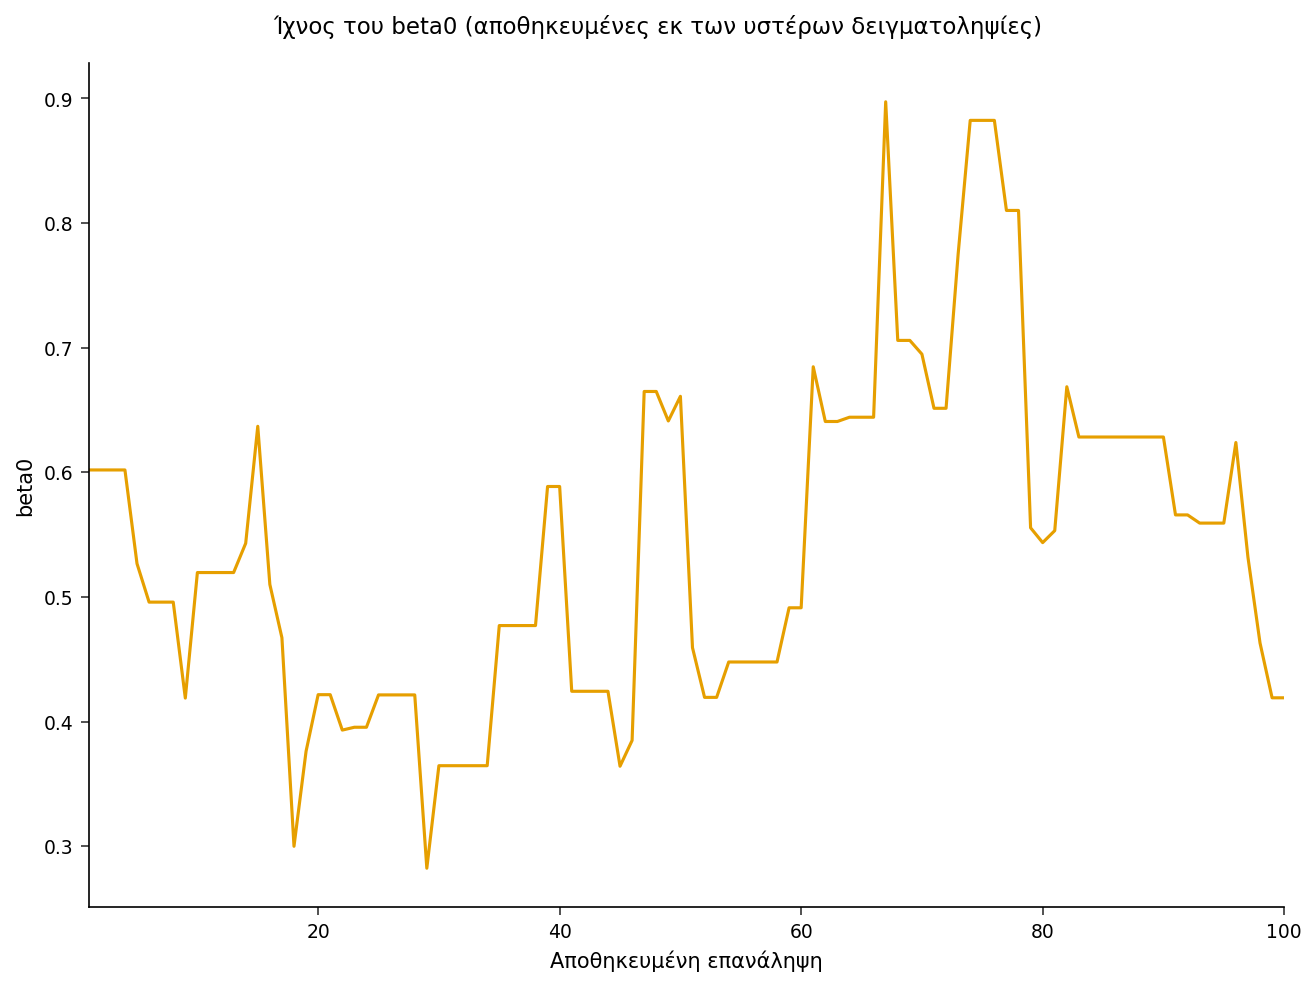

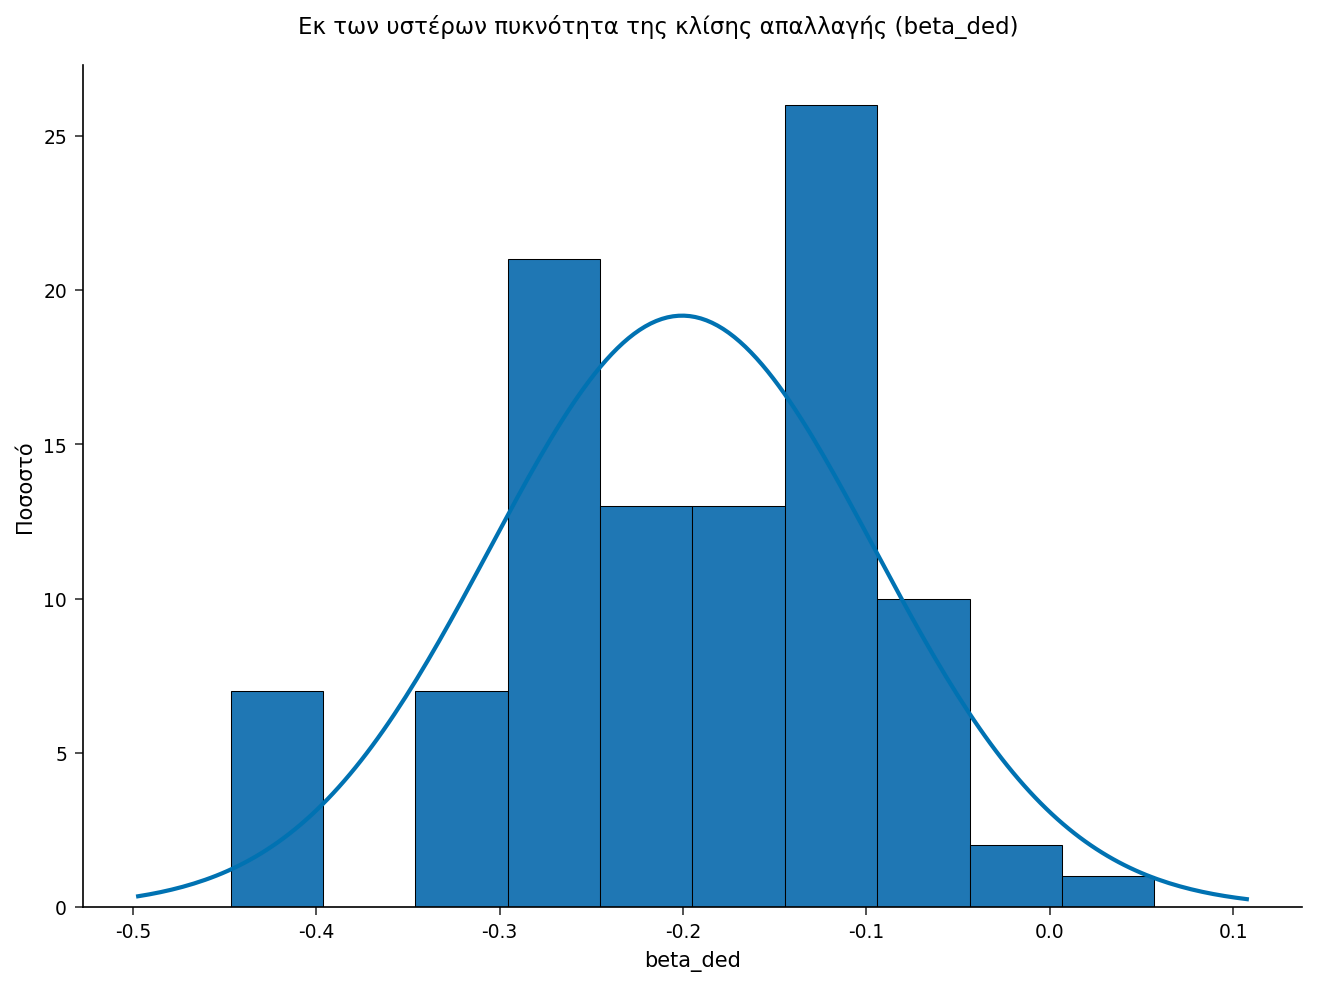

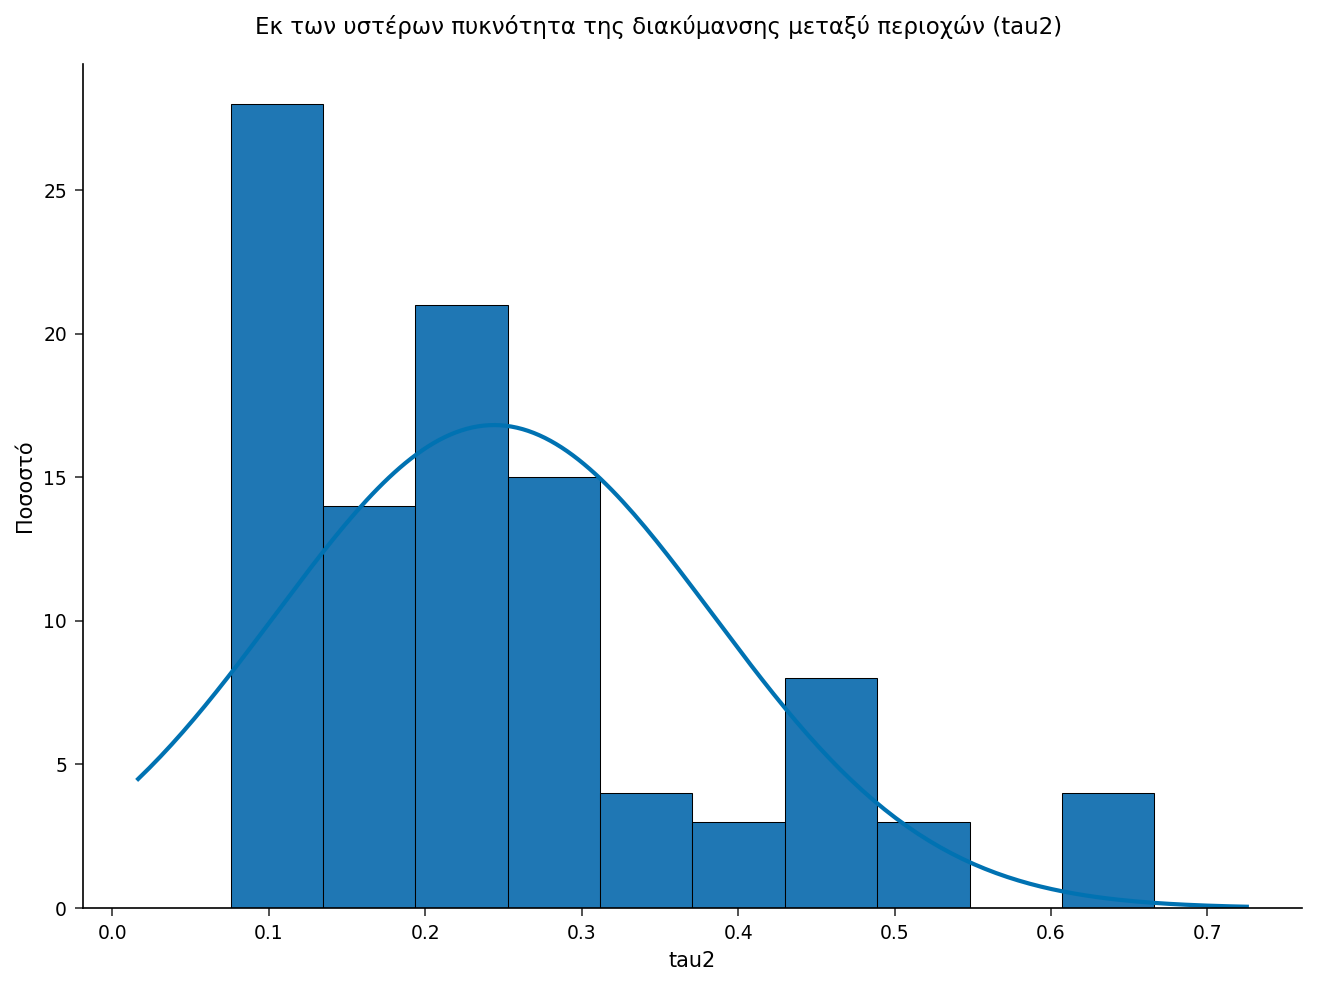

In [6]:
/* Το region_sd προστέθηκε στο post στην προβολή δεδομένων του Βήματος 5 */
ΔΕΔΟΜΕΝΑ post2;
    ΟΡΙΣΜΟΣ post;
    region_sd = sqrt(tau2);
ΕΚΤΕΛΕΣΗ;

/* Ίχνος της βασικής λογαριθμικής συχνότητας */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=post2;
    SERIES x=iter y=beta0;
    TITLE 'Ίχνος του beta0 (αποθηκευμένες εκ των υστέρων δειγματοληψίες)';
    XAXIS ΕΤΙΚΕΤΑ='Αποθηκευμένη επανάληψη';
    YAXIS ΕΤΙΚΕΤΑ='beta0';
ΕΚΤΕΛΕΣΗ;

/* Εκ των υστέρων πυκνότητα της κλίσης απαλλαγής */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITLE 'Εκ των υστέρων πυκνότητα της κλίσης απαλλαγής (beta_ded)';
    XAXIS ΕΤΙΚΕΤΑ='beta_ded';
    YAXIS ΕΤΙΚΕΤΑ='Ποσοστό';
ΕΚΤΕΛΕΣΗ;

/* Εκ των υστέρων πυκνότητα της διακύμανσης μεταξύ περιοχών */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITLE 'Εκ των υστέρων πυκνότητα της διακύμανσης μεταξύ περιοχών (tau2)';
    XAXIS ΕΤΙΚΕΤΑ='tau2';
    YAXIS ΕΤΙΚΕΤΑ='Ποσοστό';
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

**Τι απέδωσε το μοντέλο:**

- **Ανακτημένη δομή.** Οι εκ των υστέρων επιδράσεις περιοχής (`post_mean_u`) ακολουθούν τη σπαρμένη αληθή τιμή (`true_eff`) σε πρόσημο και διάταξη: η περιοχή 5 (πραγματική +0.40) είναι η υψηλότερη στο +0.36, η περιοχή 4 (πραγματική -0.30) είναι η χαμηλότερη στο -0.70, και η περιοχή 1 (πραγματική +0.05) βρίσκεται κοντά στο κέντρο στο +0.20. Η κλίση απαλλαγής `beta_ded` καταλήγει στο -0.13 (αρνητική, όπως όριζε η διαδικασία δημιουργίας δεδομένων, αν και συρρικνωμένη προς το μηδέν από το μικρό δείγμα των 96 ασφαλιστηρίων) και το `beta0` ανακτά μια βασική λογαριθμική συχνότητα 0.43 — απόδειξη ότι η ιεραρχική συνάρτηση πιθανοφάνειας Poisson και η μετατόπιση έκθεσης ορίστηκαν σωστά.
- **Η μερική συρρίκνωση σε δράση.** Συγκρίνετε τη συρρικνωμένη `relativity` του Βήματος 4 με τις ακατέργαστες συχνότητες του Βήματος 2. Η ακατέργαστη συχνότητα 3.41 της περιοχής 5 συρρικνώνεται σε σχετικότητα 1.43, και η ακατέργαστη τιμή 0.45 της περιοχής 4 ανεβαίνει σε σχετικότητα 0.49 — οι αραιές περιοχές συγκρατούνται προς το κέντρο του χαρτοφυλακίου και φέρουν τα **ευρύτερα διαστήματα αξιοπιστίας**, ακριβώς τη συμπεριφορά που θέλει ένας αναλογιστής: να μην υπερχρεώνει ούτε να υποχρεώνει μια περιοχή με βάση λίγες τυχαίες αποζημιώσεις.
- **Ποσοτικοποιημένη αβεβαιότητα.** Η εκ των υστέρων κατανομή του `sqrt(tau2)` (μέση τιμή περίπου 0.48) μετρά πόση πραγματική ετερογένεια μεταξύ περιοχών παραμένει αφού ληφθούν υπόψη η σύνθεση απαλλαγής και η έκθεση — άμεση είσοδος για την εμπιστοσύνη στις σχετικότητες περιοχών και για την αβεβαιότητα κεφαλαίου/αποθεμάτων.
- **Διαγνωστικά και προσαρμογή μοντέλου.** Το αναφερόμενο **DIC είναι 246.7**, ένα μέτρο σύγκρισης αυτής της ιεραρχικής προδιαγραφής με απλούστερες πλήρως συγκεντρωτικές ή πλήρως μη συγκεντρωτικές εναλλακτικές. Τα αποτελεσματικά μεγέθη δείγματος είναι μέτρια (το `beta_ded` κοντά στο 525, οι τυχαίες επιδράσεις και το `beta0` στις δεκάδες), και το **διαγνωστικό Geweke επισημαίνει και τις τρεις παρακολουθούμενες παραμέτρους** — το διάγραμμα ίχνους δείχνει το `beta0` να μετατοπίζεται ανοδικά στις πρώτες 100 αποθηκευμένες δειγματοληψίες. Με μόλις 96 ασφαλιστήρια-έτη και σύντομες αλυσίδες σε unlicensed mode, αυτή η μη σύγκλιση είναι αναμενόμενη· μια παραγωγική εκτέλεση θα επιμήκυνε το burn-in και τη δειγματοληψία, και πιθανώς θα επαναπαραμετροποιούσε το μοντέλο, πριν βασιστεί στα διαστήματα.

**Γιατί Μπεϋζιανή προσέγγιση εδώ:** Οι σχετικότητες συχνότητας τροφοδοτούν άμεσα την τιμολόγηση, και οι ρυθμιστικές αρχές αναμένουν όλο και περισσότερο ποσοτικοποίηση της αβεβαιότητας. Η PROC MCMC παράγει την *πλήρη εκ των υστέρων κατανομή* για κάθε περιοχή, ώστε η ασφαλιστική εταιρεία να μπορεί να δηλώσει, για παράδειγμα, ότι "η σχετικότητα συχνότητας της περιοχής 4 έχει διάστημα αξιοπιστίας 95% γύρω από την εκ των υστέρων μέση τιμή της 0.49" — μια δήλωση που οι κλασικές σημειακές εκτιμήσεις δεν μπορούν να κάνουν, και που είναι πιο πολύτιμη ακριβώς για τις μικρές περιοχές με λίγα δεδομένα.